# Task 2: Price data, TA-Lib indicators, and PyNance metrics

This notebook downloads **daily OHLCV** history for equities that appear in the bundled news sample, **cleans and types** columns, computes **TA-Lib** indicators (SMA, EMA, RSI, MACD), and adds **PyNance** return / volatility style metrics. **Kernel:** use the project `.venv` (see repo README → Environment).

> **Offline / no network:** set `YFINANCE_OFFLINE_CSV` to a local CSV path with columns `Date,Open,High,Low,Close,Adj Close,Volume` and optional `Ticker`.


In [1]:
from __future__ import annotations

# region agent log
import json as _json
import time as _time
from pathlib import Path as _PathDbg

_dbgp = _PathDbg("/home/kal/Documents/10Academy/week1/news-sentiment-analysis/.cursor/debug-499ffa.log")
try:
    _dbgp.parent.mkdir(parents=True, exist_ok=True)
    with open(_dbgp, "a", encoding="utf-8") as _df:
        _df.write(
            _json.dumps(
                {
                    "sessionId": "499ffa",
                    "hypothesisId": "H5",
                    "location": "02_nb:cell1:after_future",
                    "message": "notebook cell execution started (stdlib only)",
                    "data": {"ts": _time.time()},
                    "timestamp": int(_time.time() * 1000),
                    "runId": "nb-cell1",
                }
            )
            + "\n"
        )
except Exception:
    pass
# endregion

import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynance as pn
import talib
import yfinance as yf

# region agent log
try:
    with open(_dbgp, "a", encoding="utf-8") as _df:
        _df.write(
            _json.dumps(
                {
                    "sessionId": "499ffa",
                    "hypothesisId": "H1",
                    "location": "02_nb:cell1:after_all_imports",
                    "message": "heavy imports finished",
                    "data": {},
                    "timestamp": int(_time.time() * 1000),
                    "runId": "nb-cell1",
                }
            )
            + "\n"
        )
except Exception:
    pass
# endregion

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SAMPLE_NEWS = ROOT / "data" / "raw" / "sample_news.csv"
OFFLINE_ENV = "YFINANCE_OFFLINE_CSV"
plt.rcParams["figure.dpi"] = 110
plt.style.use("seaborn-v0_8-whitegrid")


## 1. Choose tickers (linked to Task 1 headlines)


In [2]:
def tickers_from_news(csv_path: Path, max_tickers: int = 4) -> list[str]:
    df = pd.read_csv(csv_path)
    counts = df["stock"].astype(str).str.upper().value_counts()
    return counts.head(max_tickers).index.tolist()

PRIMARY_TICKERS = tickers_from_news(SAMPLE_NEWS)
# Broad market context (always useful for narration)
PRIMARY_TICKERS = sorted(set(PRIMARY_TICKERS + ["SPY"]))
print('Tickers:', PRIMARY_TICKERS)


Tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'SPY']


## 2. Load prices into a tidy DataFrame

We standardize **`Open, High, Low, Close`**, **`Volume`** (stored as nullable integer), and **`Adj Close`** where available (`yfinance` provides it).


In [3]:
def load_prices_offline(csv_path: Path) -> pd.DataFrame:
    raw = pd.read_csv(csv_path)
    raw.columns = [str(c).strip() for c in raw.columns]
    if "Ticker" not in raw.columns:
        raw["Ticker"] = raw.get("symbol", PRIMARY_TICKERS[0])
    dt = pd.to_datetime(raw["Date"], utc=True, errors="coerce")
    raw = raw.assign(Date=dt).dropna(subset=["Date"])
    numeric = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    for c in numeric:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")
    raw["Volume"] = raw["Volume"].round().astype("Int64")
    raw = raw.dropna(subset=numeric)
    raw = raw.sort_values(["Date", "Ticker"])
    return raw.set_index(["Date", "Ticker"])[numeric]

def fetch_yfinance(tickers: list[str], period: str = "2y", interval: str = "1d") -> pd.DataFrame:
    frames = []
    for t in tickers:
        df = yf.download(t, period=period, interval=interval, progress=False, auto_adjust=False)
        if df.empty:
            continue
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [str(c[0]).strip() for c in df.columns.values]
        else:
            df.columns = [str(c).strip() for c in df.columns]
        df = df.rename(
            columns={
                "Open": "Open",
                "High": "High",
                "Low": "Low",
                "Close": "Close",
                "Adj Close": "Adj Close",
                "Volume": "Volume",
            }
        )
        df["Ticker"] = t
        frames.append(df.reset_index())
    if not frames:
        raise RuntimeError("yfinance returned no rows; check network or try OFFLINE CSV.")
    long = pd.concat(frames, ignore_index=True)
    long["Date"] = pd.to_datetime(long["Date"], utc=True)
    for c in ["Open", "High", "Low", "Close", "Adj Close", "Volume"]:
        long[c] = pd.to_numeric(long[c], errors="coerce")
    long["Volume"] = long["Volume"].round().astype("Int64")
    long = long.sort_values(["Ticker", "Date"]).set_index(["Date", "Ticker"])
    return long

offline = os.environ.get(OFFLINE_ENV)
if offline:
    prices_long = load_prices_offline(Path(offline).expanduser())
    print('Loaded offline CSV:', offline)
else:
    prices_long = fetch_yfinance(PRIMARY_TICKERS)

prices_long.head()


,,Adj Close,Close,High,Low,Open,Volume
Date,Ticker,,,,,,
2024-05-09 00:00:00+00:00,AAPL,182.905426,184.570007,184.660004,182.110001,182.559998,48983000
2024-05-10 00:00:00+00:00,AAPL,181.645142,183.050003,185.089996,182.130005,184.899994,50759500
2024-05-13 00:00:00+00:00,AAPL,184.850342,186.279999,187.100006,184.619995,185.440002,72044800
2024-05-14 00:00:00+00:00,AAPL,185.991516,187.429993,188.300003,186.289993,187.509995,52393600
2024-05-15 00:00:00+00:00,AAPL,188.263977,189.720001,190.649994,187.369995,187.910004,70400000


## 3. Data preparation and quality checks


In [4]:
def single_ticker_panel(long: pd.DataFrame, ticker: str) -> pd.DataFrame:
    df = long.xs(ticker, level="Ticker").copy()
    df = df[~df.index.duplicated(keep="last")]
    for c in ["Open", "High", "Low", "Close", "Adj Close"]:
        df[c] = df[c].astype("float64")
    df["Volume"] = df["Volume"].astype("Int64")
    # Basic validity: prices positive, High >= Low
    bad_ohlc = (df[["Open", "High", "Low", "Close"]] <= 0).any(axis=1)
    bad_hl = df["High"] < df["Low"]
    mask = bad_ohlc | bad_hl
    dropped = int(mask.sum())
    if dropped:
        print(f"[{ticker}] Dropping {dropped} invalid OHLC rows")
    df = df.loc[~mask]
    # Missing values: forward-fill small gaps in prices (stale print), leave volume NaN as NaN
    before_na = df.isna().sum().sum()
    df[["Open", "High", "Low", "Close", "Adj Close"]] = (
        df[["Open", "High", "Low", "Close", "Adj Close"]].ffill()
    )
    df = df.dropna(subset=["Close", "Adj Close"])
    print(
        f"[{ticker}] rows={len(df)} | total NA cells before ffill (all cols)={before_na} | "
        "NA volume rows=",
        int(df["Volume"].isna().sum()),
    )
    return df

# Primary analysis symbol: most news-heavy name excluding SPY
NEWS_TICKERS = [t for t in PRIMARY_TICKERS if t != "SPY"]
FOCUS = NEWS_TICKERS[0] if NEWS_TICKERS else "SPY"
print('Focus ticker for plots:', FOCUS)
ohlc = single_ticker_panel(prices_long, FOCUS)
ohlc.tail()


Focus ticker for plots: AAPL
[AAPL] rows=501 | total NA cells before ffill (all cols)=0 | NA volume rows= 0


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-05-04 00:00:00+00:00,276.829987,276.829987,280.630005,274.859985,279.660004,46668400
2026-05-05 00:00:00+00:00,284.179993,284.179993,284.570007,276.500000,276.929993,49311700
2026-05-06 00:00:00+00:00,287.510010,287.510010,288.029999,281.070007,281.920013,58336100
2026-05-07 00:00:00+00:00,287.440002,287.440002,292.130005,285.779999,289.269989,45224300
2026-05-08 00:00:00+00:00,293.320007,293.320007,294.760010,290.000000,290.010010,52631200


## 4. TA-Lib indicators

- **SMA / EMA** on `Close` with 20 / 50 / 200 where enough history exists.
- **RSI(14)** with reference bands 30 / 70.
- **MACD(12,26,9)** line, signal, histogram.


In [5]:
close = ohlc["Close"].values.astype(np.float64)
high = ohlc["High"].values.astype(np.float64)
low = ohlc["Low"].values.astype(np.float64)

n = len(close)
windows_sma = [w for w in (20, 50, 200) if n >= w]
for w in windows_sma:
    ohlc[f"SMA_{w}"] = talib.SMA(close, timeperiod=w)
for span, label in [(12, "EMA_12"), (26, "EMA_26")]:
    ohlc[label] = talib.EMA(close, timeperiod=span)

ohlc["RSI_14"] = talib.RSI(close, timeperiod=14)
macd, macd_sig, macd_hist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
ohlc["MACD"] = macd
ohlc["MACD_signal"] = macd_sig
ohlc["MACD_hist"] = macd_hist

ohlc[[c for c in ohlc.columns if c.startswith(("SMA", "EMA", "RSI", "MACD"))]].tail()


,SMA_20,SMA_50,SMA_200,EMA_12,EMA_26,RSI_14,MACD,MACD_signal,MACD_hist
Date,,,,,,,,,
2026-05-04 00:00:00+00:00,267.257500,261.463600,255.517349,271.302226,266.745543,61.763014,4.556684,3.671868,0.884815
2026-05-05 00:00:00+00:00,268.791499,261.823600,255.882349,273.283421,268.036984,67.263698,5.246438,3.986782,1.259655
2026-05-06 00:00:00+00:00,270.222000,262.131000,256.257499,275.472127,269.479430,69.410762,5.992697,4.387965,1.604732
2026-05-07 00:00:00+00:00,271.569501,262.395200,256.622699,277.313339,270.809843,69.307847,6.503496,4.811071,1.692425
2026-05-08 00:00:00+00:00,273.211501,262.802599,257.018549,279.775903,272.477262,72.937312,7.298641,5.308585,1.990056


## 5. PyNance metrics (beyond TA-Lib)

We use **`pynance.tech.simple`** for session returns and log growth on **Adj Close**, then derive **annualized rolling volatility** (\(\sqrt{252}\) scaling on daily log returns).


In [6]:
# PyNance expects a DataFrame with DatetimeIndex and price column
pn_frame = ohlc[["Adj Close"]].rename(columns={"Adj Close": "Adj Close"}).copy()
session_ret = pn.tech.simple.ret(pn_frame, selection="Adj Close", n_sessions=1)
session_ret = session_ret.rename(columns={"Return": "pn_return_1d"})
ln_gr = pn.tech.simple.ln_growth(pn_frame, selection="Adj Close", n_sessions=1)
ln_gr = ln_gr.rename(columns={"LnGrowth": "pn_ln_growth_1d"})

ohlc = ohlc.join(session_ret, how="left").join(ln_gr, how="left")
ohlc["pn_vol_20d_ann"] = (
    ohlc["pn_ln_growth_1d"].rolling(20).std() * np.sqrt(252)
)
ohlc[["pn_return_1d", "pn_ln_growth_1d", "pn_vol_20d_ann"]].describe()


,pn_return_1d,pn_ln_growth_1d,pn_vol_20d_ann
count,500.000000,500.000000,481.000000
mean,0.001101,0.000945,0.255169
std,0.017783,0.017665,0.125873
min,-0.092456,-0.097013,0.094093
25%,-0.006702,-0.006725,0.182738
50%,0.001302,0.001301,0.240268
75%,0.008995,0.008954,0.291976
max,0.153288,0.142617,0.803400


## 6. Visualizations


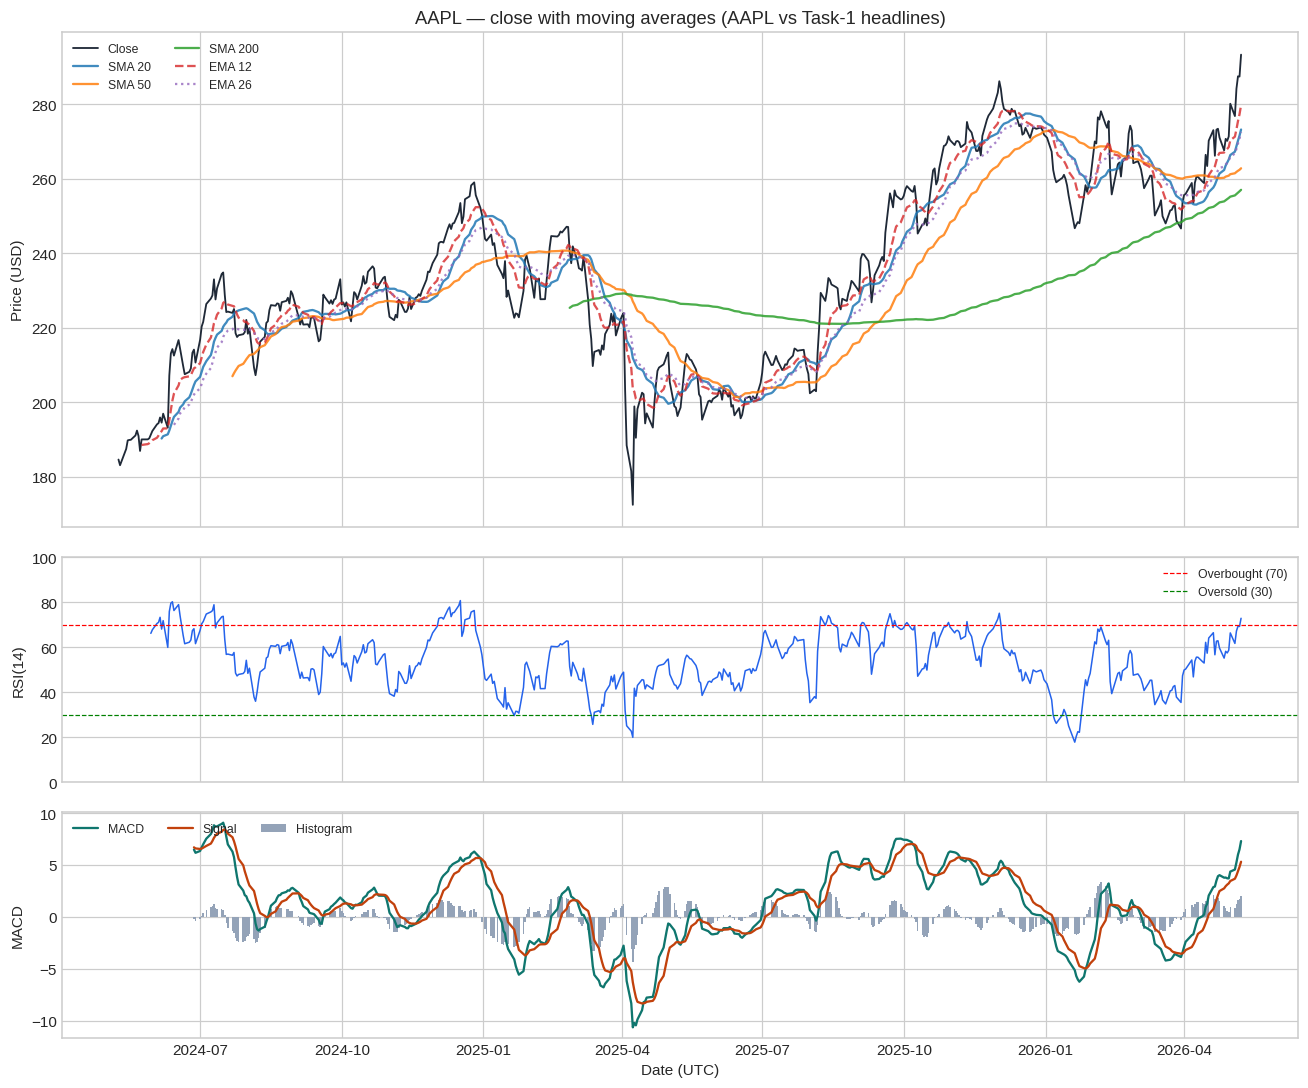

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": [2.2, 1, 1]})

ax0 = axes[0]
ax0.plot(ohlc.index, ohlc["Close"], label="Close", color="#1f2937", linewidth=1.2)
for w in windows_sma:
    if f"SMA_{w}" in ohlc:
        ax0.plot(ohlc.index, ohlc[f"SMA_{w}"], label=f"SMA {w}", alpha=0.85)
ax0.plot(ohlc.index, ohlc["EMA_12"], label="EMA 12", linestyle="--", alpha=0.8)
ax0.plot(ohlc.index, ohlc["EMA_26"], label="EMA 26", linestyle=":", alpha=0.8)
ax0.set_title(f"{FOCUS} — close with moving averages ({FOCUS} vs Task-1 headlines)")
ax0.set_ylabel("Price (USD)")
ax0.legend(loc="upper left", ncol=2, fontsize=8)

ax1 = axes[1]
ax1.plot(ohlc.index, ohlc["RSI_14"], color="#2563eb", linewidth=1)
ax1.axhline(70, color="red", linestyle="--", linewidth=0.8, label="Overbought (70)")
ax1.axhline(30, color="green", linestyle="--", linewidth=0.8, label="Oversold (30)")
ax1.set_ylabel("RSI(14)")
ax1.set_ylim(0, 100)
ax1.legend(loc="upper right", fontsize=8)

ax2 = axes[2]
ax2.plot(ohlc.index, ohlc["MACD"], label="MACD", color="#0f766e")
ax2.plot(ohlc.index, ohlc["MACD_signal"], label="Signal", color="#c2410c")
ax2.bar(ohlc.index, ohlc["MACD_hist"], label="Histogram", color="#94a3b8", width=1.0)
ax2.set_ylabel("MACD")
ax2.legend(loc="upper left", ncol=3, fontsize=8)
ax2.set_xlabel("Date (UTC)")

plt.tight_layout()
plt.show()


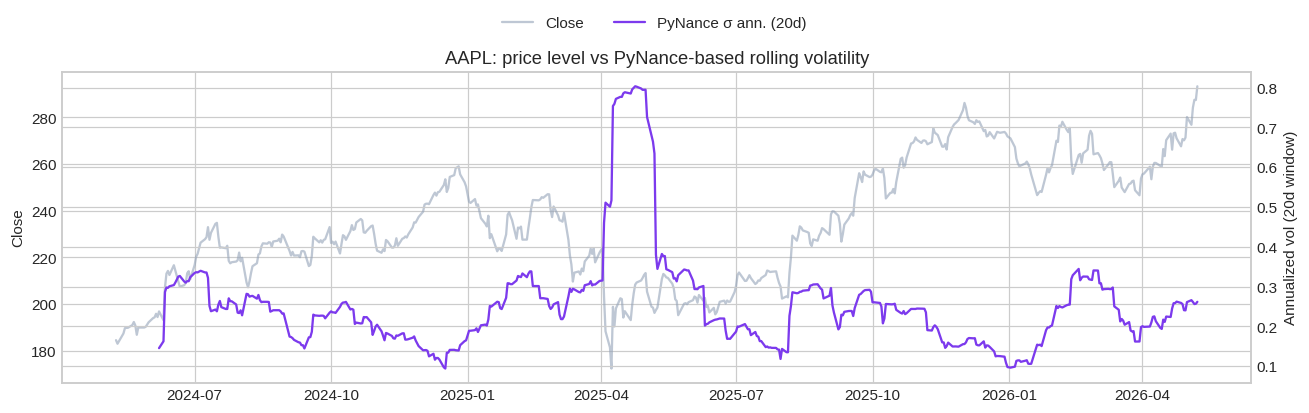

In [8]:
# Volatility context: how wild were recent 20d windows vs level?
fig, ax = plt.subplots(figsize=(12, 3.5))
ax2 = ax.twinx()
ax.plot(ohlc.index, ohlc["Close"], color="#94a3b8", alpha=0.6, label="Close")
ax2.plot(ohlc.index, ohlc["pn_vol_20d_ann"], color="#7c3aed", label="PyNance σ ann. (20d)")
ax.set_ylabel("Close")
ax2.set_ylabel("Annualized vol (20d window)")
ax.set_title(f"{FOCUS}: price level vs PyNance-based rolling volatility")
fig.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()


## 7. Summary — preparation and quality

| Step | Action |
|------|--------|
| Source | `yfinance` daily bars or `YFINANCE_OFFLINE_CSV` |
| Types | `float64` OHLC/Adj Close; `Int64` volume |
| Invalid rows | Non-positive OHLC or `High < Low` removed |
| Gaps | Small price gaps forward-filled; rows missing close dropped |
| Indicators | TA-Lib on `Close`; PyNance returns on `Adj Close` |

**Interpretation prompts (fill with numbers after re-run):** latest RSI vs 30/70, whether MACD recently crossed signal, how 50/200 SMAs relate to trend, and whether `pn_vol_20d_ann` spikes align with drawdowns in the plot.
